# Exercise - Multiple Linear Regression



It's time for you to apply your knowledge to a new dataset. So that not too much changes come at once, we will stick to the cars topic and work with the **car seats data**. A company that makes car seats would like to construct a model to predict sales and they need your help!

You will find the file called `carseats.csv` in the data folder. It contains 400 observations on the following 11 variables:
* **Sales**:         Unit sales (in thousands) at each location
* **CompPrice**:     Price charged by competitor at each location
* **Income**:        Community income level (in thousands of dollars)
* **Advertising**:   Local advertising budget for company at each location (in thousands of dollars)
* **Population**:    Population size in region (in thousands)
* **Price**:         Price company charges for car seats at each site
* **ShelveLoc**:     A factor with levels Bad, Good and Medium indicating the quality of the shelving location for the car seats at each site
* **Age**:           Average age of the local population
* **Education**:     Education level at each location
* **Urban**:         A factor with levels No and Yes to indicate whether the store is in an urban or rural location
* **US**:            A factor with levels No and Yes to indicate whether the store is in the US or not

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set figure stile and size for entire notebook
sns.set_style("ticks")
plt.rcParams["figure.figsize"] = (7, 4)

**(a) Load the data**

In [2]:
df = pd.read_csv("data/carseats.csv")

**(b) Visualize the data with the appropriate plots.** 

<br>
<details><summary>
Click here for a hint…
</summary>
Check the documentation for seaborn's pair plots. 
</details>

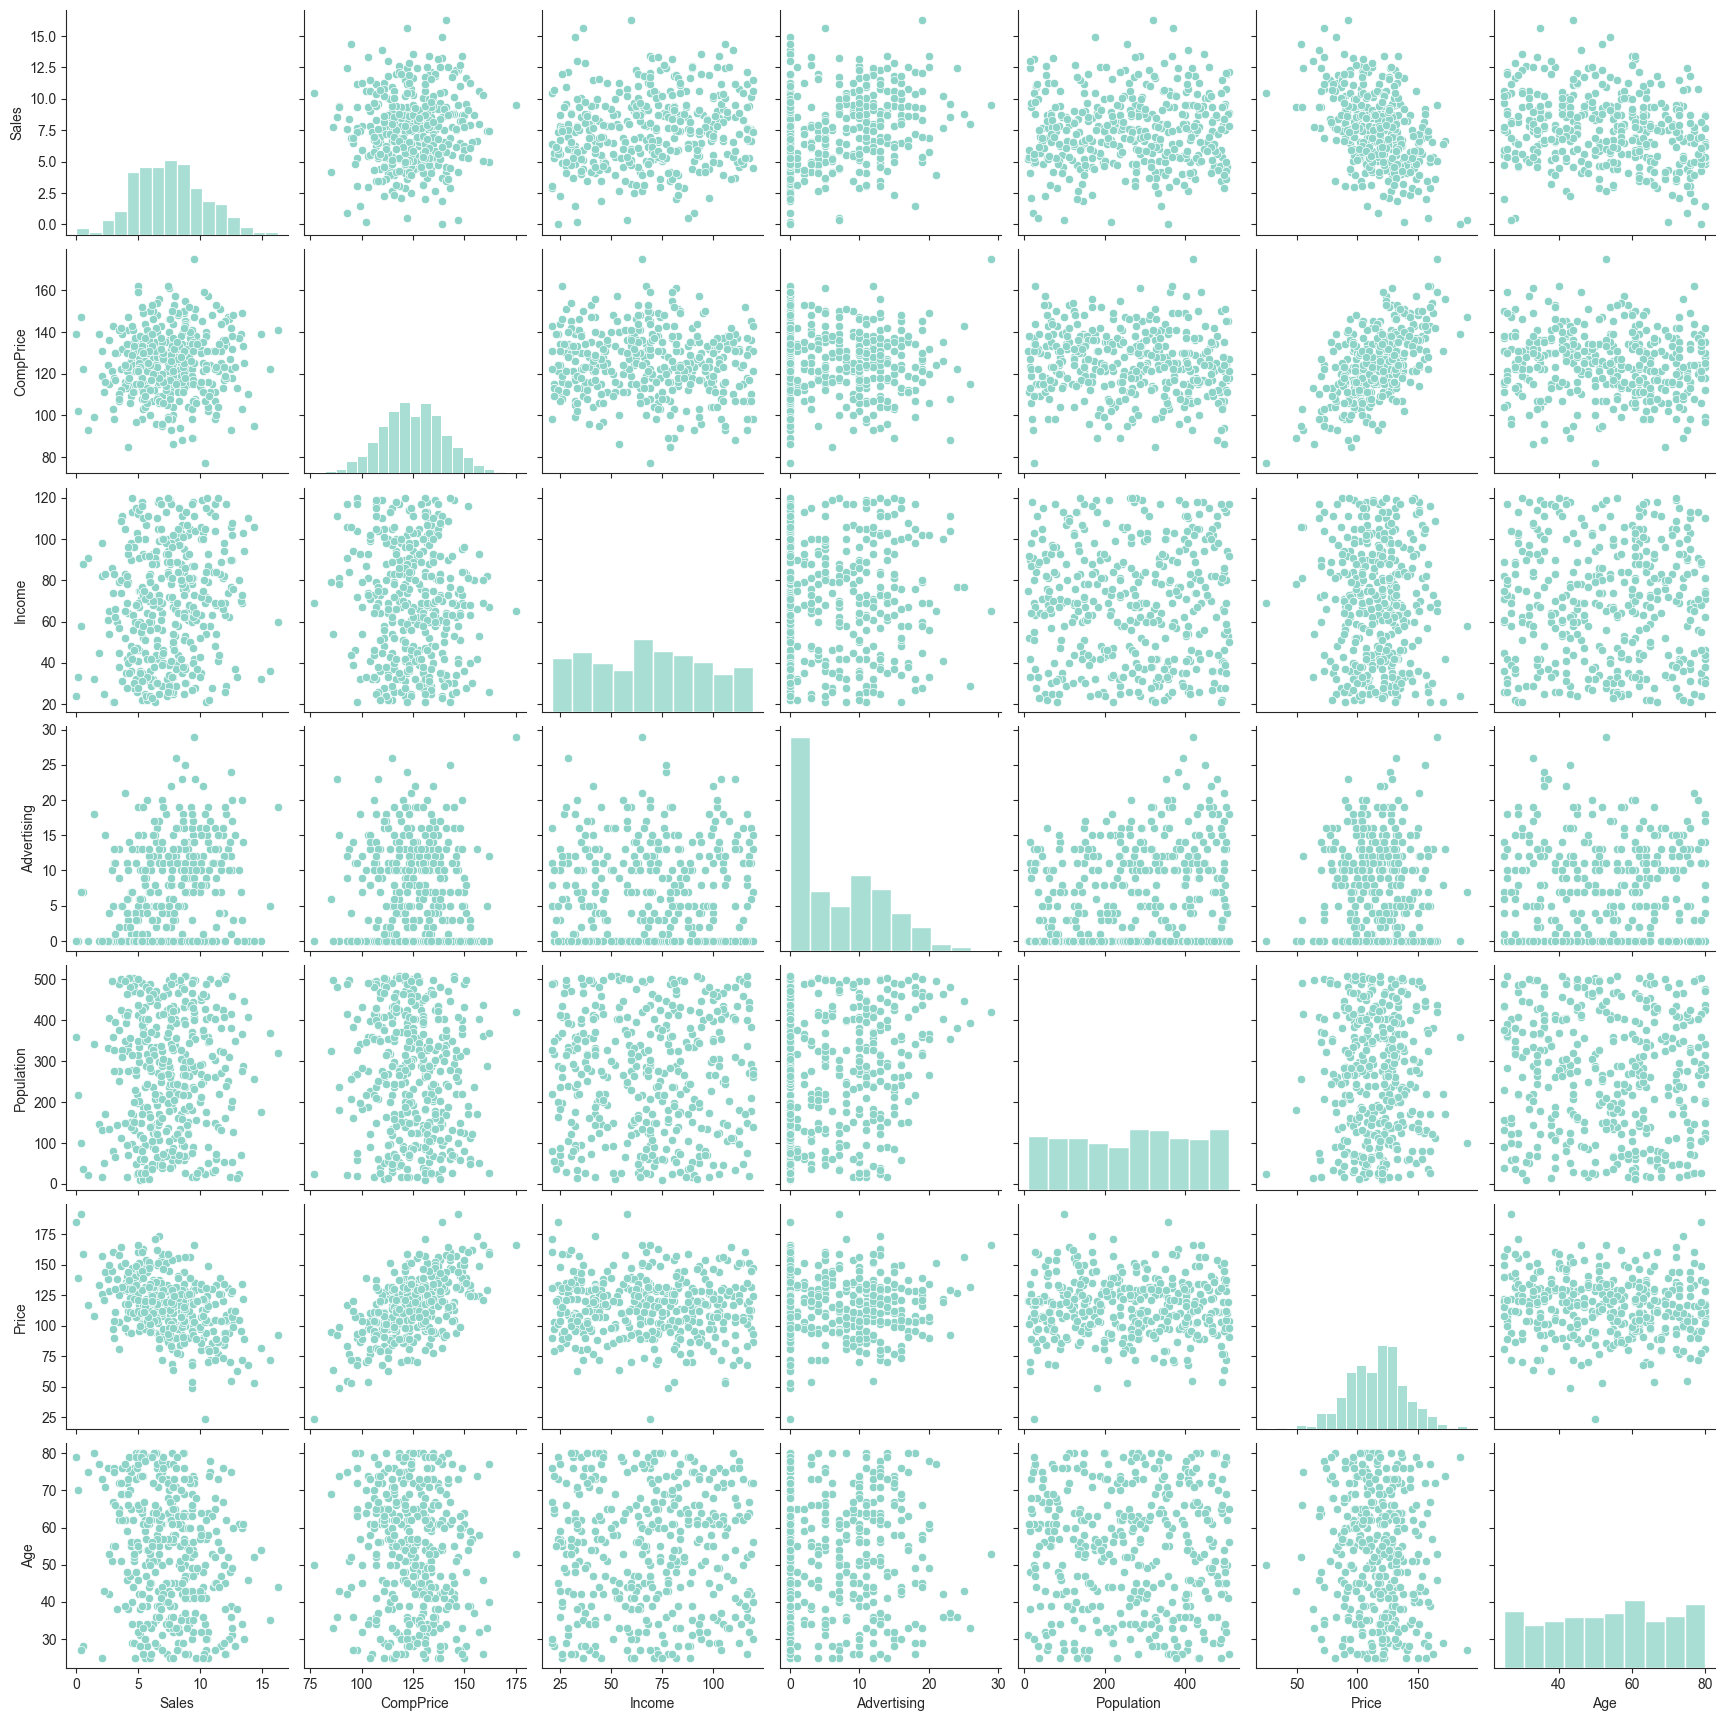

In [6]:
# Plot pair plot of potential features
sns.pairplot(df[["Sales", "CompPrice", "Income", "Advertising", "Population", "Price", "Age"]]);

**(c) What trends do you see in the data?**

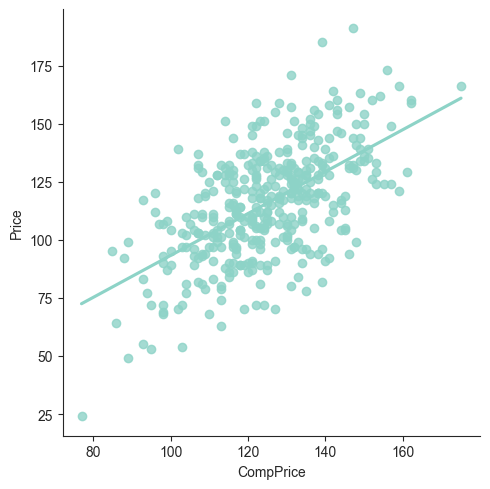

In [ ]:
# relevant: "Sales", "Advertising"
# most: "CompPrice", "Price"
# maybe: "Price", "Advertising"
# useless: "Population", "Advertising"

# Elastic Net would help to calibrate corellated features (see next repo)

# We can use seaborns .lmplot function to plot our data including a regression line
sns.lmplot(x="CompPrice", y="Price", data=df, ci=None);

**(d) Find the single best predictor for a simple linear regression.**

<br>
<details><summary>
Click here for a hint…
</summary>
Fit a linear model to all possible explanatory variables and pick best one.
</details>

In [62]:
# Define model input X features
#X0 = df[["Price"]]
X1 = df[["Advertising", "Price", "CompPrice", "Age", "Population", "Education"]]
y1 = df.Sales
X1.shape
# Fit linear regression model
lin_reg1 = LinearRegression()
lin_reg1.fit(X1, y1)
# Calculate intercept and coefficient
intercept = lin_reg1.intercept_
coefficients = lin_reg1.coef_
print("Intercept:", intercept.round(4))
print("Coefficients:", coefficients.round(4))
# Calculate r-squared
y1_hat = lin_reg1.predict(X1)
print("R-squared:", round(r2_score(y1, y1_hat), 4))

Intercept: 8.9627
Coefficients: [ 0.1345 -0.0928  0.0922 -0.0453 -0.0002 -0.0478]
R-squared: 0.5256


**(e) Fit a model with all possible explanatory variables.**

In [ ]:
# Define model input X with all explanatory features
X2 = df.drop(columns=["Sales", "US", "ShelveLoc", "Urban"])
y2 = df.Sales
X2.shape
# Fit linear regression model
lin_reg2 = LinearRegression()
lin_reg2.fit(X2, y2)
# Calculate intercept and coefficient
intercept = lin_reg2.intercept_
coefficients = lin_reg2.coef_
print("Intercept:", intercept.round(4))
print("Coefficients:", coefficients.round(4))
# Calculate r-squared
y2_hat = lin_reg2.predict(X2)
print("R-squared:", round(r2_score(y2, y2_hat), 4))

Intercept: 7.7077
Coefficients: [ 9.390e-02  1.290e-02  1.309e-01 -1.000e-04 -9.250e-02 -4.500e-02
 -4.000e-02]
R-squared: 0.5417


**(f) What's the best model according to $R^2$?**

In [52]:
# Define model input X with four features
# X3 = df.drop(columns=["Sales", "US", "ShelveLoc", "Urban", "Population", "Education", "Age"])
X3 = df.drop(columns=["Sales", "US", "ShelveLoc", "Urban", "Population", "Education"])
y3 = df.Sales
X3.shape
# Fit linear regression model
lin_reg3 = LinearRegression()
lin_reg3.fit(X3, y3)
# Calculate intercept and coefficient
intercept = lin_reg3.intercept_
coefficients = lin_reg3.coef_
print("Intercept:", intercept.round(4))
print("Coefficients:", coefficients.round(4))
# Calculate r-squared
y3_hat = lin_reg3.predict(X3)
print("R-squared:", round(r2_score(y3, y3_hat), 4))

Intercept: 7.1092
Coefficients: [ 0.0939  0.0131  0.1306 -0.0925 -0.045 ]
R-squared: 0.5403


**(g) Remove a couple of explanatory variables. How does $R^2$ change?**

In [57]:
# Define model input X with four features
# X4 = df.drop(columns=["Sales", "US", "ShelveLoc", "Urban", "Population", "Education", "Age"])
X4 = df.drop(columns=["Sales", "US", "ShelveLoc", "Urban", "Population"])
y4 = df.Sales
X4.shape
# Fit linear regression model
lin_reg4 = LinearRegression()
lin_reg4.fit(X4, y4)
# Calculate intercept and coefficient
intercept = lin_reg4.intercept_
coefficients = lin_reg4.coef_
print("Intercept:", intercept.round(4))
print("Coefficients:", coefficients.round(4))
# Calculate r-squared
y4_hat = lin_reg4.predict(X4)
print("R-squared:", round(r2_score(y4, y4_hat), 4))

Intercept: 7.6518
Coefficients: [ 0.0941  0.0129  0.1302 -0.0926 -0.0449 -0.0393]
R-squared: 0.5416


**(h) Repeat the process for the adjusted $R^2$.**

In [63]:
# Define function for calculating adjusted r-squared
def adjusted_r_squared(r_squared, X):
    adjusted_r2 = 1 - ((1 - r_squared) * (len(X) - 1) / (len(X) - X.shape[1] - 1))
    return adjusted_r2

# Store model data as tuples: (y, y_hat, X)
model_data = [
    (y1, y1_hat, X1),
    (y2, y2_hat, X2),
    (y3, y3_hat, X3),
    (y4, y4_hat, X4)
]

# Initialize model_dict
model_dict = {
    "Model 1": None,
    "Model 2": None,
    "Model 3": None
}

# Compute adjusted R-squared for each model using a loop
for i, (y_i, y_hat_i, X_i) in enumerate(model_data, start=1):
    # Convert DataFrame to NumPy array if needed for compatibility
    X_i_array = X_i.values if hasattr(X_i, 'values') else X_i
    model_dict[f"Model {i}"] = adjusted_r_squared(r2_score(y_i, y_hat_i), X_i_array)

# Print results
print("Adjusted R²")
for model_name, model_value in model_dict.items():
    print(f"{model_name}: {model_value}")

# Find best model
best_model = max(model_dict, key=model_dict.get)
best_index = int(best_model.split()[-1]) - 1
best_X_i = model_data[best_index][2] 
print(f"The best model is: {best_model} with value {model_dict[best_model]} and features: {', '.join(best_X_i.columns)}")

Adjusted R²
Model 1: 0.518382234984953
Model 2: 0.5346245385872532
Model 3: 0.5344645936376402
Model 4: 0.5346245385872532
The best model is: Model 2 with value 0.5346245385872532 and features: CompPrice, Income, Advertising, Price, Age, Education


**(i) What are your most interesting findings?**

In [ ]:
# Some features such as Age can lead to worse R² if other features such as Population and Education are removed

In [ ]:
#from mlxtend.evaluate import bias_variance_decomp
#from sklearn.linear_model import LinearRegression

#model = LinearRegression()

# Decomposes your test error into exact bias and variance values
#avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
#    lin_reg4, X4, y_train, X_test, y_test, 
#    loss='mse', num_rounds=200, random_seed=42

<br>
<br> 
<br>

----